# Venn Diagram
for SMBE poster instead of [upset plots](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/new_refGenome/upset_p2.v.p2.ipynb) which might be better for this visualization

## 0. load libraries

In [18]:
library(tidyverse)
library(VennDiagram)
library(RColorBrewer) # for color palette

## 1. load CSVs

### all genes

In [4]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res',
    pattern = '\\.csv$',
    full.names = TRUE
    )

# read each csv
file_list <- lapply(files, read.csv)

# name list elements after the files
names(file_list) <- tools::file_path_sans_ext(basename(files))

# check things worked
names(file_list)
head(file_list$bb_cc)

[1] "bb_cc" "bc_bb" "bc_cc" "bc_hc" "bc_wc" "bh_ch" "bh_hh" "bw_cw" "bw_ww"
[10] "cb_bb" "cb_bc" "cb_cc" "cb_ch" "cb_cw" "ch_cc" "ch_hc" "cw_cc" "cw_ch"
[19] "cw_wc" "hb_bb" "hb_bh" "hb_cb" "hc_cc" "hc_hh" "hh_cc" "hh_ch" "wb_bb"
[28] "wb_bw" "wb_cb" "wc_cc" "wc_hc" "wc_ww" "wh_hw" "ww_cc" "ww_cw"

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1.973312e+03,-0.0332488130,0.10018698,0.82750435,0.4079513,0.8964045,0.9922542,2495.69160,2092.46282,⋯,2997.1598,989.093923,1560.977872,2330.6831,2070.68147,1769.86179,1994.901145,1739.660029,2926.81774,2569.347527
2,LOC144621269,2.477696e+03,-0.0078655573,0.14736612,0.62056406,0.5348865,0.9348872,0.9804099,52.27077,1648.11743,⋯,14829.0276,3.288758,7.480725,629.9143,41.13318,108.14038,10700.556957,17.774304,417.80514,10534.217403
3,LOC111120925,1.301645e+02,0.0085061583,0.15147791,-0.68050588,0.4961842,0.9239532,0.9787085,66.52643,23.22715,⋯,375.5976,0.000000,3.740362,459.2279,76.65728,29.97951,5.799131,1.110894,11.99963,9.671321
4,Trnae-cuc-2,1.043799e-02,0.0001907784,0.32997597,-0.01429643,0.9885935,NA,0.9752358,0.00000,0.00000,⋯,0.0000,0.000000,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000
5,Trnae-cuc-3,3.559860e-02,-0.0026528705,0.33519956,0.19674097,0.8440303,NA,0.9699419,0.00000,0.00000,⋯,0.0000,0.000000,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000
6,LOC144621283,8.712697e+02,-0.0037226610,0.09670776,0.08951601,0.9286718,0.9959300,0.9930926,540.76486,870.51301,⋯,604.2222,1004.715522,771.761424,893.0560,866.60123,794.45702,586.872081,1420.833446,596.70865,618.964524


### DEGs

In [5]:
deg_list <- lapply(file_list, function(df) {
  df %>% filter(abs(log2FoldChange) >= "1" & padj <= 0.05)
})

names(deg_list)
head(deg_list$bb_cc)

[1] "bb_cc" "bc_bb" "bc_cc" "bc_hc" "bc_wc" "bh_ch" "bh_hh" "bw_cw" "bw_ww"
[10] "cb_bb" "cb_bc" "cb_cc" "cb_ch" "cb_cw" "ch_cc" "ch_hc" "cw_cc" "cw_ch"
[19] "cw_wc" "hb_bb" "hb_bh" "hb_cb" "hc_cc" "hc_hh" "hh_cc" "hh_ch" "wb_bb"
[28] "wb_bw" "wb_cb" "wc_cc" "wc_hc" "wc_ww" "wh_hw" "ww_cc" "ww_cw"

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111102506,948.578114,1.113463,1.3782539,-3.721539,1.980124e-04,4.376733e-02,2.293073e-01,822.0766309,290.844253,⋯,112.13493,230.21305,275.54002,1135.877800,179.4902221,280.52256,796.800632,234.39864,285.80926,204.172325
2,LOC111117765,948.580792,1.019382,0.7028216,-4.035920,5.438871e-05,1.923475e-02,1.031210e-01,1030.2093271,726.100756,⋯,1376.10241,948.80664,354.08763,785.360948,624.4763979,619.93344,1457.901593,607.65903,376.35189,546.966914
3,LOC111104782,61.439122,1.360622,1.1165575,-3.947402,7.900399e-05,2.436630e-02,8.045647e-02,73.1790758,105.027091,⋯,39.19279,32.06539,92.26227,8.127927,183.2296018,26.76742,59.151139,36.65950,33.81713,8.596729
4,LOC144619911,263.266792,-3.777067,3.9685711,3.967465,7.264103e-05,2.349671e-02,1.289212e-01,0.0000000,20.197518,⋯,0.00000,2431.21424,1034.83357,1.015991,0.9348449,0.00000,2.319652,5.55447,4.36350,0.000000
5,LOC111105268,370.537252,-1.988343,2.3808844,3.881096,1.039866e-04,2.795036e-02,1.789722e-01,0.9503776,1852.112359,⋯,17.41902,204.72518,351.59406,42.671617,365.5243586,94.22132,336.349612,1969.61509,644.70715,53.729559
6,LOC111102028,7.951088,21.008371,3.3828306,-6.378646,1.786602e-10,2.961740e-07,6.332811e-07,0.0000000,3.029628,⋯,59.87787,12.33284,0.00000,1.015991,0.0000000,0.00000,0.000000,0.00000,0.00000,4.298365


## 2. Plot venn diagrams

In [19]:
# 3 colors from palette
myCol <- brewer.pal(3, "Pastel2")

### Same treatment, different timing, compared to CC

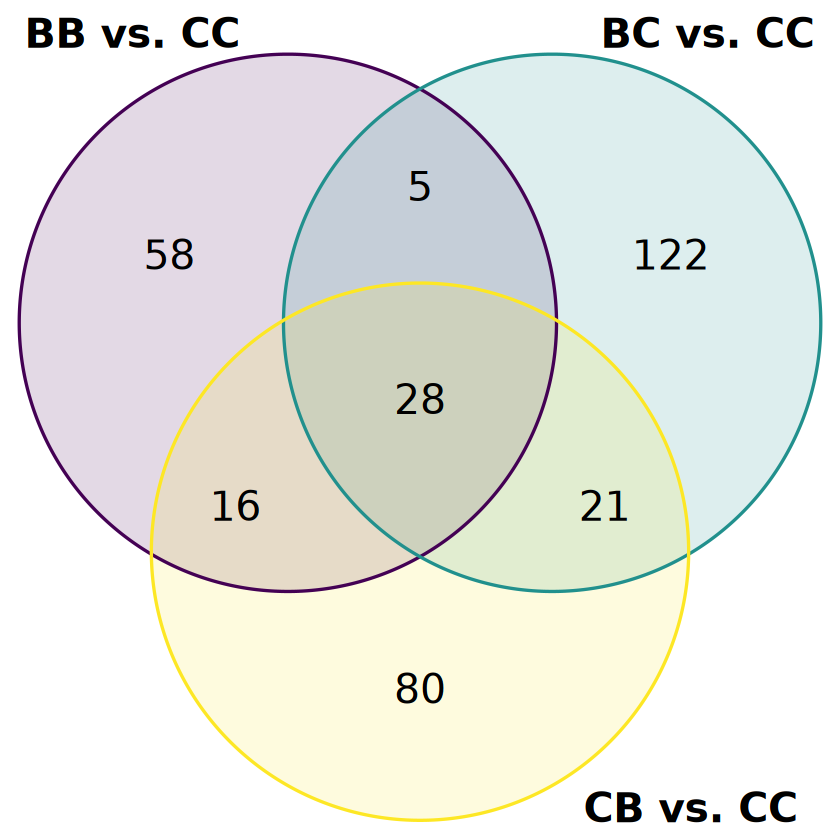

In [35]:
venn.plot <- venn.diagram(
    x = list(
        bb_cc = deg_list$bb_cc$Gene,
        bc_cc = deg_list$bc_cc$Gene,
        cb_cc = deg_list$cb_cc$Gene
    ),
    category.names = c('BB vs. CC', 'BC vs. CC', 'CB vs. CC'),
    filename = NULL,
    
     # Circles
        lwd = 2, # outer line thickness
       # lty = 'blank',
    col=c("#440154ff", '#21908dff', '#fde725ff'),
    fill = c(alpha("#440154ff",0.3), alpha('#21908dff',0.3), alpha('#fde725ff',0.3)),
        
        # Numbers
        cex = 2,
        #fontface = "bold",
        fontfamily = "sans",
        
        # Set names
        cat.cex = 2,
        cat.fontface = "bold",
        cat.default.pos = "outer",
        cat.pos = c(-27, 27, 135),
        cat.dist = c(0.055, 0.055, 0.085),
        cat.fontfamily = "sans",
        rotation = 1
)


grid.draw(venn.plot)